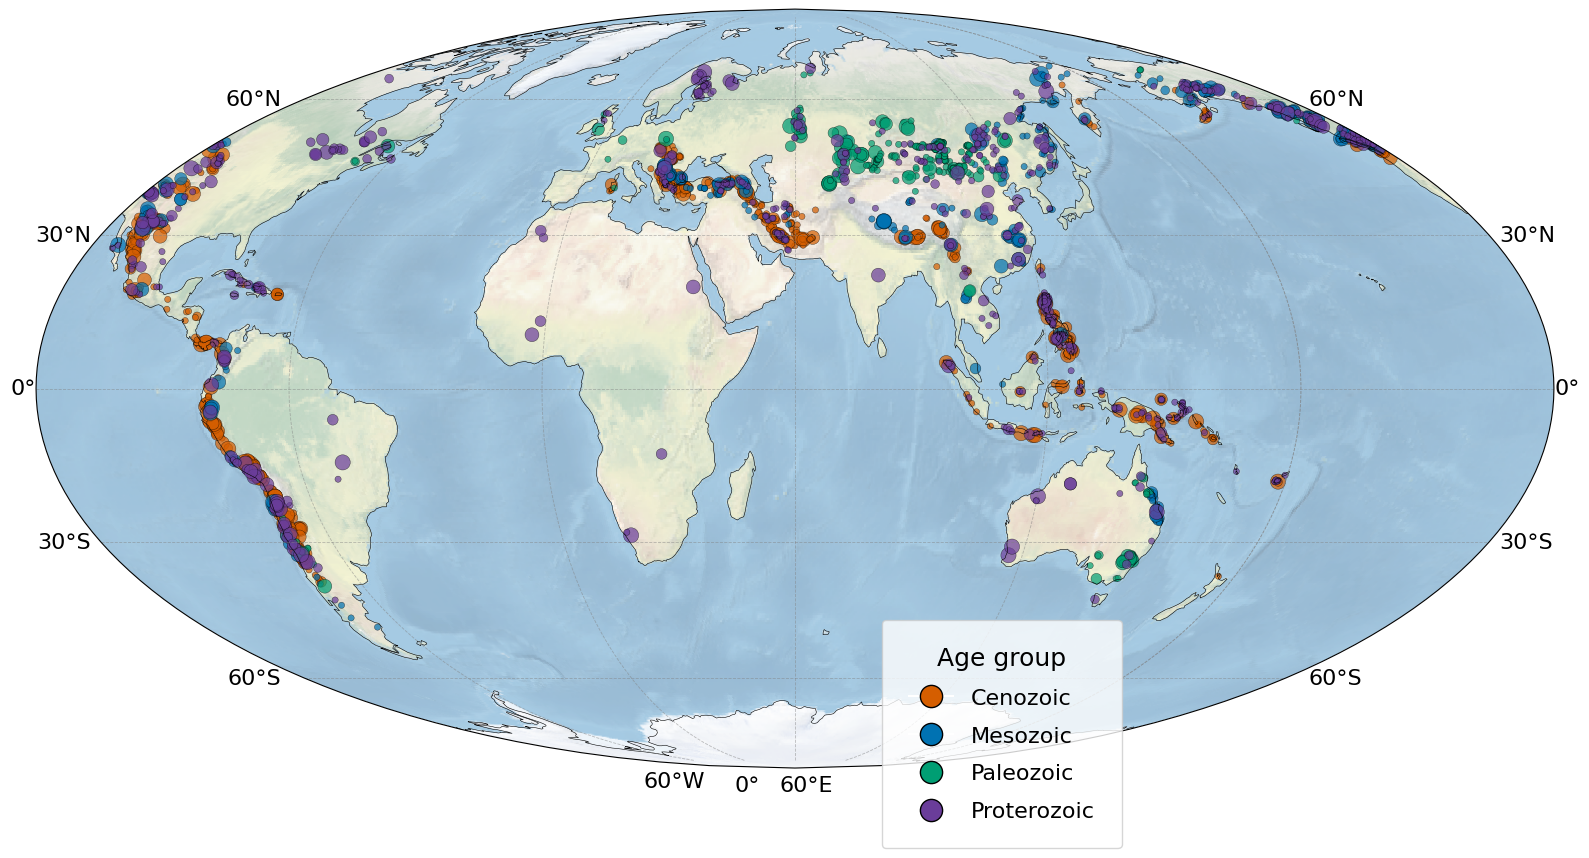

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================
# LOAD DATA
# =========================

df = pd.read_csv("deposit_coords_weight.csv")

df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["age (Ma)"] = pd.to_numeric(df["age (Ma)"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

df = df.dropna(subset=["lat", "lon", "weight"])


# =========================
# AGE CLASSIFICATION
# =========================

def classify_age(age):
    if age < 66:
        return "Cenozoic"
    elif age < 252:
        return "Mesozoic"
    elif age < 539:
        return "Paleozoic"
    else:
        return "Proterozoic"

df["age_group"] = df["age (Ma)"].apply(classify_age)


# =========================
# SIZE SCALING
# =========================

w = df["weight"]
df["size"] = w * 20


# =========================
# COLORS
# =========================

colors = {
    "Cenozoic": "#D55E00",
    "Mesozoic": "#0072B2",
    "Paleozoic": "#009E73",
    "Proterozoic": "#6A3D9A"
}


# =========================
# CREATE MAP
# =========================

fig = plt.figure(figsize=(16, 12))

ax = plt.axes(projection=ccrs.Mollweide(central_longitude=60))
ax.set_global()


# =========================
# BACKGROUND (HILLSHADE)
# =========================

ax.stock_img()

# fade relief slightly
for im in ax.get_images():
    im.set_alpha(0.7)

# coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)


# =========================
# GRIDLINES
# =========================

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    x_inline=False,
    linewidth=0.6,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# show labels only left and right
gl.top_labels = False
gl.bottom_labels = False

# grid spacing
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

# label font size
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}

ax.text(0.49,-0.03, "60°E", transform=ax.transAxes, fontsize=16)
ax.text(0.46,-0.03, "0°", transform=ax.transAxes, fontsize=16)
ax.text(0.40,-0.025, "60°W", transform=ax.transAxes, fontsize=16)


# =========================
# PLOT DEPOSITS
# =========================

for age in colors:

    sub = df[df["age_group"] == age]

    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=sub["size"],
        color=colors[age],
        edgecolor="black",
        linewidth=0.3,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        label=age
    )


# =========================
# LEGEND
# =========================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=k,
        markerfacecolor=v,
        markeredgecolor='black',
        markersize=16
    )
    for k, v in colors.items()
]

ax.legend(
    handles=legend_elements,
    title="Age group",
    loc="lower left",
    bbox_to_anchor=(0.55, -0.12),
    frameon=True,
    fontsize=16,
    title_fontsize=18,
    borderpad=1.2,
    labelspacing=0.8
)


# =========================
# EXPORT
# =========================

plt.tight_layout()

# plt.savefig("porphyry_global.png", dpi=300)

plt.show()